#  OpenCV & MediaPipe 


---
##  C'est quoi OpenCV ?

**OpenCV** (Open Source Computer Vision Library) est une bibliothèque open-source spécialisée dans le **traitement d'images** et la **vision par ordinateur**.

###  Rôle
Permettre aux machines de **lire, analyser et comprendre** des images et des vidéos.

###  Avantages
| Avantage | Détail |
|---|---|
|  Open Source | Gratuit, multiplateforme (Windows, Linux, macOS) |
|  Haute performance | Optimisé en C/C++, support GPU |
|  Multi-langages | Python, Java, JavaScript |
|  +2500 algorithmes | Filtres, détection, segmentation, ML… |
|  Temps réel | Traitement vidéo en direct |

###  Installation
```bash
pip install opencv-python mediapipe numpy matplotlib
```

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print(f'✅ OpenCV version : {cv2.__version__}')
print(f'✅ NumPy version  : {np.__version__}')

✅ OpenCV version : 4.13.0
✅ NumPy version  : 2.4.4


---
##  Lire une image depuis un dossier & Ouvrir la caméra

### — Lire une image depuis un dossier
> `cv2.imread()` charge l'image. On convertit BGR→RGB pour l'afficher avec matplotlib.

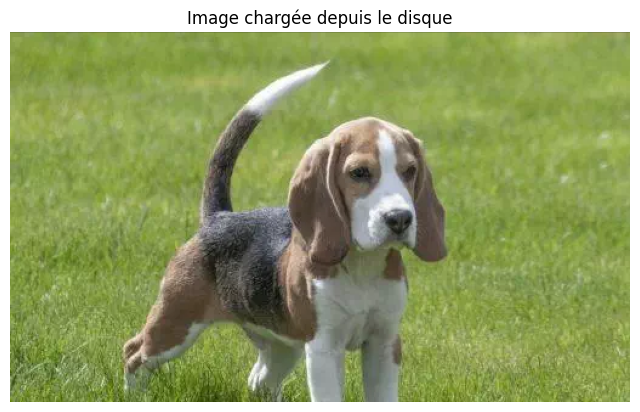

 Image chargée | Taille : (305, 511, 3)


In [2]:
# Lire une image depuis le disque
image_path = 'image/chien.png'   # <-- modifiez ce chemin

img = cv2.imread(image_path)

if img is None:
    print(' Image introuvable — vérifiez le chemin !')
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR → RGB
    plt.figure(figsize=(8, 5))
    plt.imshow(img_rgb)
    plt.title('Image chargée depuis le disque')
    plt.axis('off')
    plt.show()
    print(f' Image chargée | Taille : {img.shape}')

###  Ouvrir la caméra en temps réel
> `cv2.VideoCapture(0)` ouvre la webcam. Appuyez sur **Q** pour quitter.

In [3]:
# Ouvrir la caméra
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print(' Impossible d accéder à la caméra.')
else:
    print(' Appuyez sur Q pour quitter')
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        cv2.imshow('Caméra en direct', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()
    print(' Caméra fermée.')

 Appuyez sur Q pour quitter
 Caméra fermée.


---
## Traitements d'Images — Toutes les Techniques

> **Convention :** Option A = fichier image  |  Option B = caméra temps réel

---
### Lecture & Écriture
> Charger/sauvegarder images (JPG, PNG) et vidéos (MP4) avec `cv2.imread`, `cv2.imwrite`, `cv2.VideoWriter`.

Image sauvegardée sous output/sortie_image.png


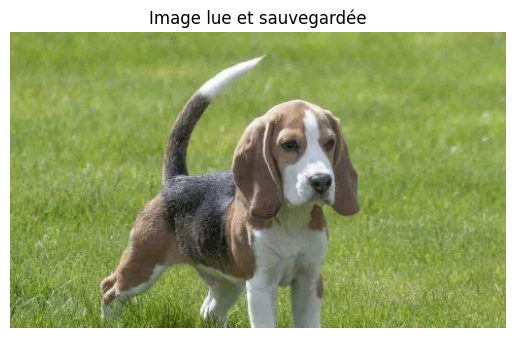

In [5]:
import os

# Option A — Lire et sauvegarder une image
img = cv2.imread('image/chien.png')

if img is not None:
    os.makedirs('output', exist_ok=True)
    cv2.imwrite('output/sortie_image.png', img)  # sauvegarder en PNG
    print('Image sauvegardée sous output/sortie_image.png')
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Image lue et sauvegardée')
    plt.axis('off')
    plt.show()
else:
    print(' Image introuvable.')

In [7]:
import os

# Option B — Capturer depuis la caméra et enregistrer une vidéo MP4
os.makedirs('livesave', exist_ok=True)
cap    = cv2.VideoCapture(0)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out    = cv2.VideoWriter('livesave/capture.mp4', fourcc, 20.0, (640, 480))

print(' Enregistrement... Q pour arrêter.')
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    out.write(frame)
    cv2.imshow('Enregistrement Vidéo', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
out.release()
cv2.destroyAllWindows()
print(' Vidéo sauvegardée sous livesave/capture.mp4')

 Enregistrement... Q pour arrêter.
 Vidéo sauvegardée sous livesave/capture.mp4


---
###  Transformation d'Images
> Conversion en gris, flou gaussien, redimensionnement, rotation, déformations géométriques.

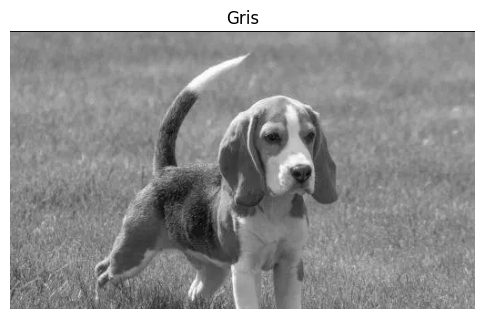

Image "Gris" sauvegardée sous output/transformations/gris.png


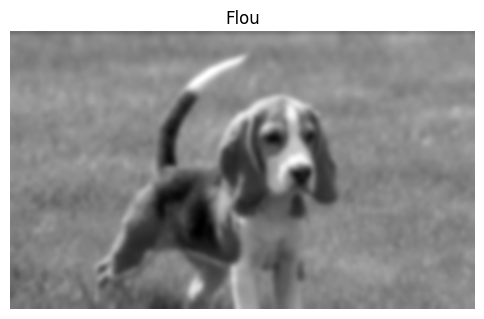

Image "Flou" sauvegardée sous output/transformations/flou.png


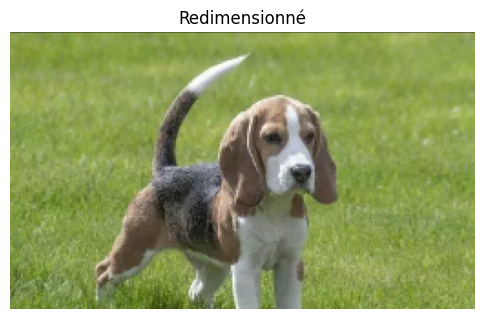

Image "Redimensionné" sauvegardée sous output/transformations/redimensionné.png


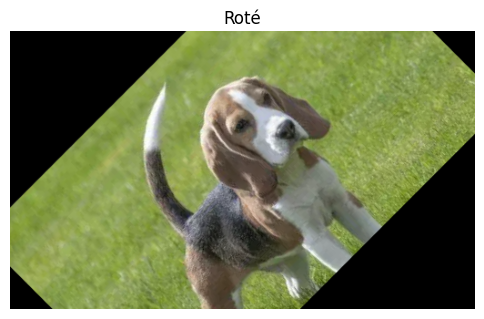

Image "Roté" sauvegardée sous output/transformations/roté.png


In [8]:
# Option A — Transformations sur une image existante
img = cv2.imread('image/chien.png')

if img is not None:
    h, w = img.shape[:2]

    # 1. Niveaux de gris
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    

    # 2. Flou Gaussien (noyau 15x15)
    flou = cv2.GaussianBlur(gris, (15, 15), 0)


    # 3. Redimensionnement à 50%
    redim = cv2.resize(img, (w // 2, h // 2))


    # 4. Rotation de 45 degrés
    centre = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(centre, 45, 1.0)
    rot = cv2.warpAffine(img, M, (w, h))

    # Liste des transformations
    transformations = [
        ('Gris', gris),
        ('Flou', flou),
        ('Redimensionné', redim),
        ('Roté', rot)
    ]

    # Créer le dossier de sortie
    os.makedirs('output/transformations', exist_ok=True)

    # Afficher et sauvegarder chaque image
    for i, (titre, img_transformée) in enumerate(transformations):
        plt.figure(figsize=(6, 4))
        if len(img_transformée.shape) == 2:  # Image en niveaux de gris
            plt.imshow(img_transformée, cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(img_transformée, cv2.COLOR_BGR2RGB))
        plt.title(titre)
        plt.axis('off')
        plt.show()

        # Sauvegarder l'image transformée
        chemin_sauvegarde = f'output/transformations/{titre.lower()}.png'
        cv2.imwrite(chemin_sauvegarde, img_transformée)
        print(f'Image "{titre}" sauvegardée sous {chemin_sauvegarde}')
else:
    print(' Image introuvable.')    
    











In [9]:
# Option B — Transformations en temps réel
cap = cv2.VideoCapture(0)
print(' Transformations en direct — Q pour quitter')

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    h, w   = frame.shape[:2]
    gris   = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    cv2.imshow('Original',      frame)
    cv2.imshow('Gris',          gris)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

 Transformations en direct — Q pour quitter


In [10]:
# Option B — Transformations en temps réel
# Ajoutez ici les transformations gris 
#, flou, redimensionnement et rotation en temps réel
cap = cv2.VideoCapture(0)
print(' Transformations en direct — Q pour quitter')
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    h, w   = frame.shape[:2]
    gris   = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    flou   = cv2.GaussianBlur(gris, (15, 15), 0)
    redim  = cv2.resize(frame, (w // 2, h // 2))
    centre = (w // 2, h // 2)
    M      = cv2.getRotationMatrix2D(centre, 45, 1.0)
    rot    = cv2.warpAffine(frame, M, (w, h))

    # Afficher les transformations
    cv2.imshow('Original',      frame)
    cv2.imshow('Gris',          gris)
    cv2.imshow('Flou',          flou)
    cv2.imshow('Redimensionné', redim)
    cv2.imshow('Roté',          rot)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows() 












 Transformations en direct — Q pour quitter


---
###  Opérations Morphologiques
> Érosion, dilatation, ouverture et fermeture pour **nettoyer** et **structurer** les formes.

Erosio: Réduit les zones blanches

Dilatation: Agrandit les zones blanches

Ouverture: Érosion → puis Dilatation

Fermeture: Dilatation → puis Érosion

In [ ]:
# Option A — Morphologie sur image
img = cv2.imread('image/chien.png', cv2.IMREAD_GRAYSCALE)
#complete
    



In [4]:
# Option B — Morphologie en temps réel
#Erosio & Dilatation


noyau = np.ones((5, 5), np.uint8)
cap   = cv2.VideoCapture(0)


In [5]:
# Option B — Morphologie en temps réel
#Fermeture & Ouverture


---
###  Détection de Contours
> `cv2.Canny()` extrait les bords. `cv2.findContours()` détecte les formes fermées.

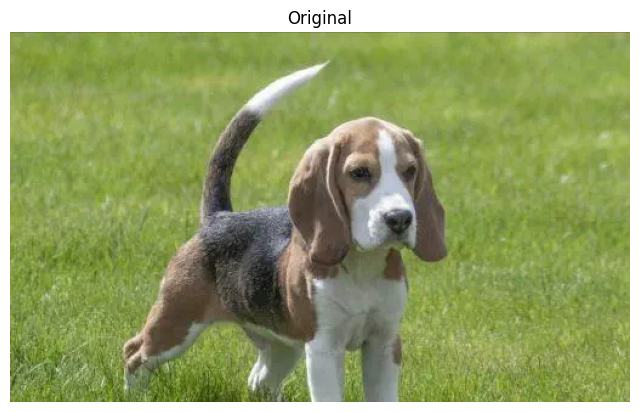

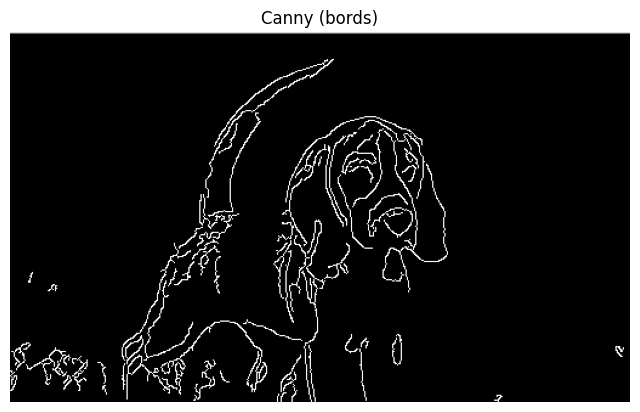

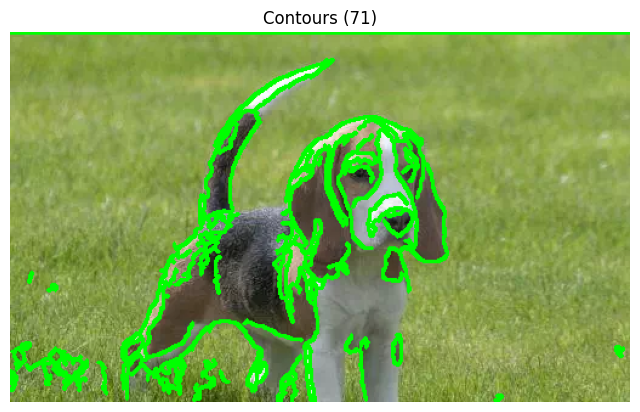

 71 contours détectés


In [6]:
# Option A — Canny + findContours sur image
img = cv2.imread('image/chien.png')

if img is not None:
    gris  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    flou  = cv2.GaussianBlur(gris, (5, 5), 0)
    canny = cv2.Canny(flou, 50, 150)

    cnts, _ = cv2.findContours(canny, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    img_cnt = img.copy()
    cv2.drawContours(img_cnt, cnts, -1, (0, 255, 0), 2)

    for titre, im in [
        ('Original', img),
        ('Canny (bords)', canny),
        (f'Contours ({len(cnts)})', img_cnt)
    ]:
        plt.figure(figsize=(8, 5))
        if len(im.shape) == 2:
            plt.imshow(im, cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        plt.title(titre)
        plt.axis('off')
        plt.show()

    print(f' {len(cnts)} contours détectés')

In [7]:
# Option B — Contours en temps réel
cap = cv2.VideoCapture(0)
print(' Contours en direct — Q pour quitter')


 Contours en direct — Q pour quitter


---
###  Analyse de Canaux — RGB, Histogrammes & Seuillage Adaptatif
> Séparer les canaux R, G, B, visualiser les histogrammes et appliquer un seuillage adaptatif.

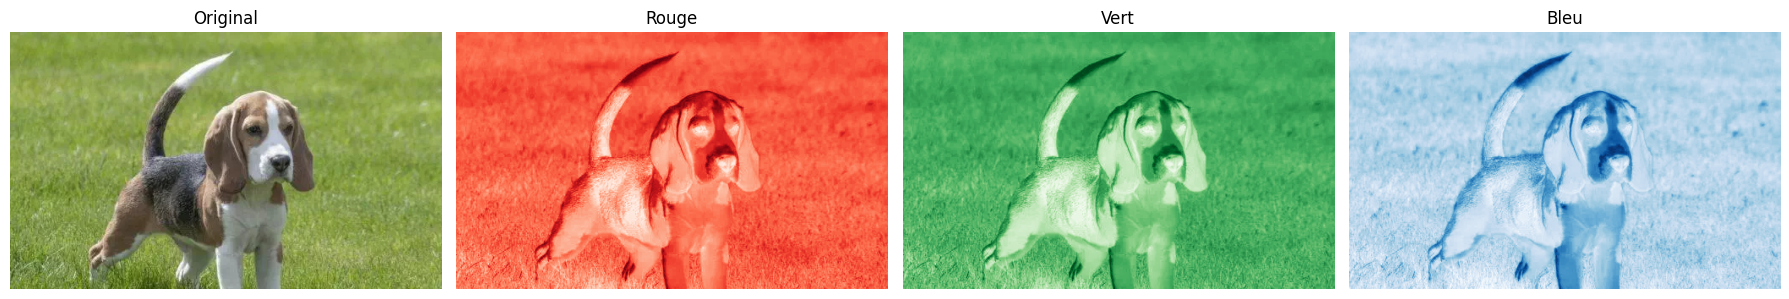

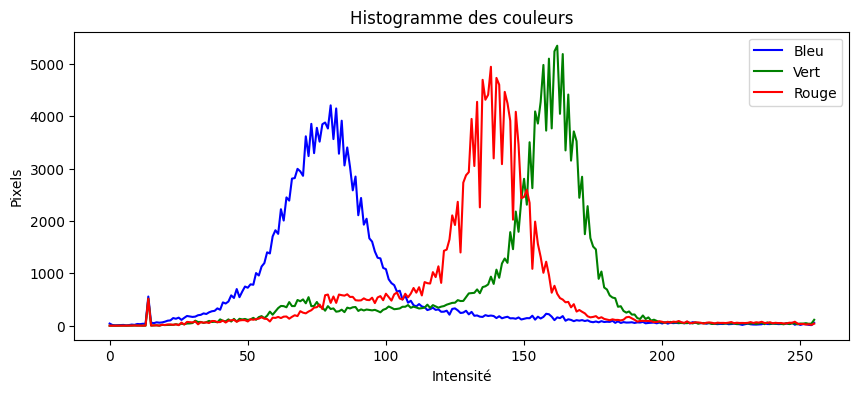

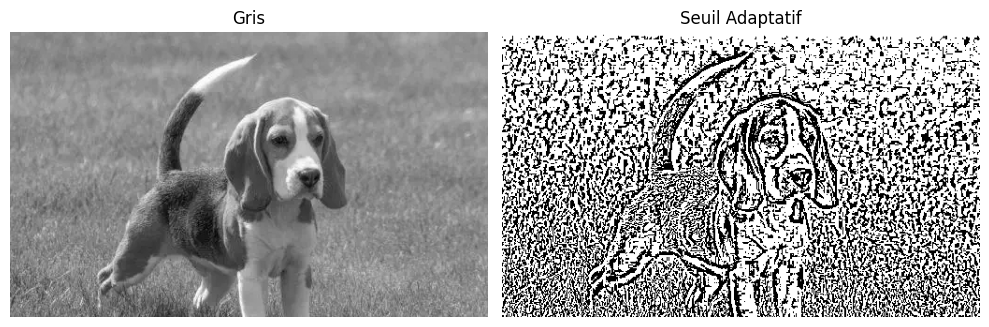

In [8]:
# Option A — Canaux + histogramme + seuillage
img = cv2.imread('image/chien.png')

if img is not None:
    B, G, R = cv2.split(img)

    # Affichage des canaux
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, titre, im, cmap in zip(axes,
        ['Original', 'Rouge', 'Vert', 'Bleu'],
        [img, R, G, B],
        [None, 'Reds', 'Greens', 'Blues']):
        ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB) if cmap is None else im, cmap=cmap)
        ax.set_title(titre)
        ax.axis('off')
    plt.tight_layout(); plt.show()

    # Histogramme
    plt.figure(figsize=(10, 4))
    for canal, col, lbl in zip(cv2.split(img), ('b','g','r'), ('Bleu','Vert','Rouge')):
        plt.plot(cv2.calcHist([canal], [0], None, [256], [0,256]), color=col, label=lbl)
    plt.title('Histogramme des couleurs'); plt.xlabel('Intensité'); plt.ylabel('Pixels')
    plt.legend(); plt.show()

    # Seuillage adaptatif
    gris  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    adapt = cv2.adaptiveThreshold(gris, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY, 11, 2)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(gris,  cmap='gray'); axes[0].set_title('Gris');             axes[0].axis('off')
    axes[1].imshow(adapt, cmap='gray'); axes[1].set_title('Seuil Adaptatif'); axes[1].axis('off')
    plt.tight_layout(); plt.show()

In [9]:
# Option B — Canaux en temps réel
cap = cv2.VideoCapture(0)
print(' Canaux en direct — Q pour quitter')

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    B, G, R = cv2.split(frame)
    cv2.imshow('Original',  frame)
    cv2.imshow('Rouge', R)
    cv2.imshow('Vert',  G)
    cv2.imshow('Bleu',  B)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

 Canaux en direct — Q pour quitter


---
###  Traitement Vidéo — Détection de Mouvement & Suivi
> Comparer deux frames successives pour détecter les **zones en mouvement** et encadrer les objets qui bougent.

In [ ]:
# Détection de mouvement en temps réel
cap        = cv2.VideoCapture(0)
frame_prev = None
print(' Détection de mouvement — Q pour quitter')

while cap.isOpened():
    #..................
    
    

 Détection de mouvement — Q pour quitter


---
###  Segmentation — GrabCut & K-Means
> **GrabCut** isole un objet de l'arrière-plan. **K-Means** regroupe les pixels par couleur similaire.

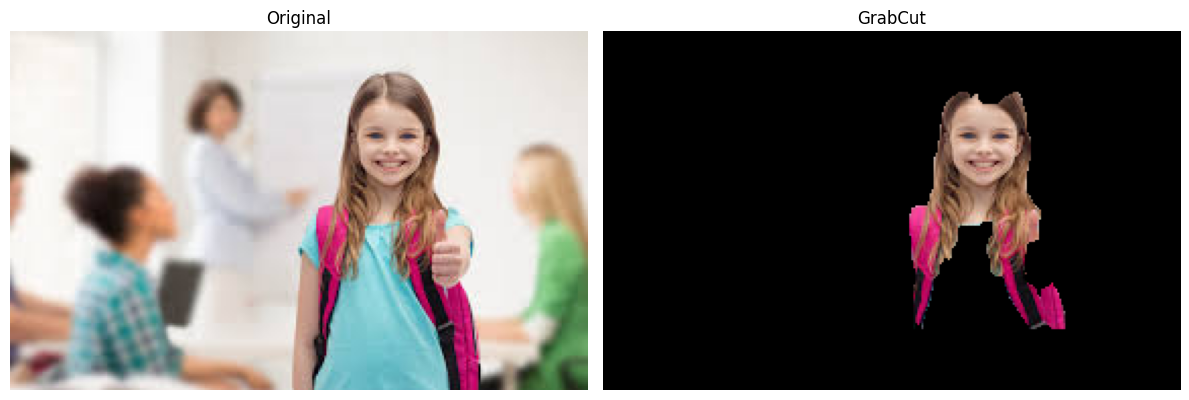

In [ ]:
# Option A — Segmentation GrabCut
img = cv2.imread('image\image.png')

if img is not None:
    #............
    

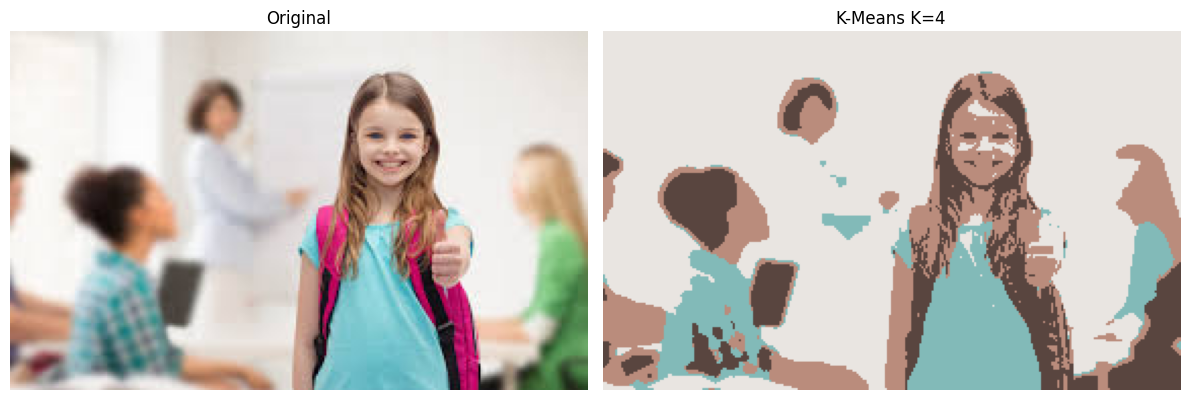

In [ ]:
# Option B — Segmentation K-Means (4 couleurs dominantes)
img = cv2.imread('image\image.png')

if img is not None:
    #..........

---
## MediaPipe — Vision par Ordinateur Avancée

**MediaPipe** est un framework Google pour détecter **mains, visages, postures** en temps réel.

| Fonctionnalité | Description |
|---|---|
|  Hand Tracking | 21 landmarks par main |
|  Suivi du regard | Iris tracking haute précision |
|  Reconnaissance faciale | 468 landmarks du visage |
|  Expressions | Sourire, clignement, surprise |
|  Estimation de posture | 33 landmarks du corps |
|  Multi-personnes | Plusieurs personnes simultanées |

```bash
pip install mediapipe
```

In [41]:
import mediapipe as mp
print(f' MediaPipe version : {mp.__version__}')

 MediaPipe version : 0.10.9


---
### Hand Tracking — Suivi des Mains
> MediaPipe détecte **21 landmarks** par main. Fonctionne pour 1 ou 2 mains simultanément.
> Chaque landmark est numéroté : 0=poignet, 4=pouce, 8=index, 12=majeur, 16=annulaire, 20=auriculaire.

In [ ]:
import mediapipe as mp

mp_hands  = mp.solutions.hands
mp_draw   = mp.solutions.drawing_utils

cap = cv2.VideoCapture(0)
print(' Hand Tracking — Q pour quitter')

with mp_hands.Hands(max_num_hands=2,
                    min_detection_confidence=0.7,
                    min_tracking_confidence=0.7) as hands:
    #...............

🖐 Hand Tracking — Q pour quitter


In [ ]:

# Option B — Reconnaissance de gestes 
# Ajoutez ici la fonction fingers_up() et gesture_name() pour reconnaître les gestes de la main en temps réel.



















---
###  Suivi du Regard — Iris Tracking
> FaceMesh avec `refine_landmarks=True` permet de localiser les **iris** gauche (468-472) et droit (473-477).

In [ ]:
# Option A — Face Mesh 
#  Suivi du Regard

mp_face_mesh = mp.solutions.face_mesh
mp_draw      = mp.solutions.drawing_utils


👁 Suivi du Regard — Q pour quitter


In [ ]:

# # Option B — Face Mesh  seulement œil droit & seulement œil gauche & deux yeux visibles 
mp_face_mesh = mp.solutions.face_mesh



In [ ]:

# Détecter si les œils et cacher par les mains.
mp_face_mesh = mp.solutions.face_mesh
mp_hands = mp.solutions.hands



---
### Reconnaissance Faciale Avancée & Expressions
> **468 landmarks** par visage. On mesure le ratio d'ouverture de la bouche (sourire) et l'EAR de l'oeil (clignement).
> Support multi-visages avec `max_num_faces=3`.

In [ ]:
# Option B — Reconnaissance d'expressions faciales (sourire, clignement)
import mediapipe as mp
import math

mp_face_mesh = mp.solutions.face_mesh
mp_draw      = mp.solutions.drawing_utils
mp_styles    = mp.solutions.drawing_styles

#........
#


Reconnaissance Faciale — Q pour quitter


---
###  Estimation de la Posture — Pose Estimation
> **33 landmarks** du corps. On calcule les **angles articulaires** (coude, genou) avec la formule cosinus.

In [ ]:
import mediapipe as mp
import numpy as np

mp_pose  = mp.solutions.pose
mp_draw  = mp.solutions.drawing_utils
mp_style = mp.solutions.drawing_styles

#  Pose Estimation en temps réel
# pose estimation  "images , video "

Posture Estimation — Q pour quitter


---
###  Personnes — Détection Simultanée


In [ ]:
import cv2
import mediapipe as mp

mp_face = mp.solutions.face_detection
mp_draw = mp.solutions.drawing_utils



###  Multi-Personnes — Détection Simultanée
> Soustraction de fond (MOG2) pour localiser plusieurs personnes, combinée avec Pose Estimation.

In [ ]:
import cv2
import mediapipe as mp

mp_face = mp.solutions.face_detection
mp_draw = mp.solutions.drawing_utils

cap = cv2.VideoCapture(0)





Face-based people detection — Q pour quitter


---
##  Récapitulatif Complet

| Section | Technique | Fonctions clés |
|---|---|---|
|OpenCV intro | `cv2.__version__` |
| Lire image | `cv2.imread`, `cvtColor` |
| Caméra | `cv2.VideoCapture(0)` |
| Lecture/Écriture | `imwrite`, `VideoWriter` |
| Transformations | `GaussianBlur`, `resize`, `warpAffine` |
| Morphologie | `erode`, `dilate`, `morphologyEx` |
| Contours | `Canny`, `findContours` |
| Canaux | `split`, `calcHist`, `adaptiveThreshold` |
|Mouvement | `absdiff`, `BackgroundSubtractorMOG2` |
|Segmentation | `grabCut`, `kmeans` |
| Hand Tracking | `mp.solutions.hands` |
| Iris | `FaceMesh(refine_landmarks=True)` |
| Expressions | `FaceMesh`, EAR, ratio sourire |
| Posture + Angles | `mp.solutions.pose`, cos |
| Multi-Personnes | `MOG2` + `Pose` |

> **Astuce** : testez toujours Option A (image fixe) avant Option B (caméra temps réel).

Multi-emotion detection

In [ ]:

mp_face = mp.solutions.face_mesh

cap = cv2.VideoCapture(0)


